# Download IG price history (IG demo account)

Pulls **OHLC candles** for an IG market (`EPIC`, `RESOLUTION`, `DAYS_BACK` —
default is `IX.D.NASDAQ.IFA.IP` / `DAY` / the last 1 day) over a recent window
from the IG REST API, then can save them to a timestamped
`data/ig_<epic-slug>_<resolution-suffix>_<timestamp>.csv` and/or upsert them into the
resolution-specific `candles_<suffix>` table (e.g. `candles_1d`) of
`data/ig_market_data.db` (same schema the sibling `view_ig_prices.ipynb`
reads) — each output is independently toggled via `SAVE_CSV` / `SAVE_DB` in
the config cell.

**Credentials and config** are read from a `.env` file in this folder
(git-ignored). Keys expected:

| var | meaning |
| --- | --- |
| `IG_API_KEY` | IG API key for the **demo** environment |
| `IG_USERNAME` | IG demo login |
| `IG_PASSWORD` | IG demo password |
| `IG_ACCOUNT_TYPE` | `demo` or `live` (default `demo`) |
| `IG_EPIC` | market to pull candles for (default `IX.D.NASDAQ.IFA.IP`) |
| `IG_RESOLUTION` | IG candle resolution (default `DAY`) |
| `IG_DAYS_BACK` | lookback window in calendar days (default `1`) |
| `IG_SAVE_CSV` | write the timestamped CSV (`true`/`false`, default `true`) |
| `IG_SAVE_DB` | upsert into the SQLite DB (`true`/`false`, default `false`) |

The download needs `requests` + `python-dotenv`. `pandas` / `matplotlib` are
used for the optional preview and chart at the end.

## 1. Load config from `.env`

Uses [`python-dotenv`](https://pypi.org/project/python-dotenv/) - run the
install line once if it's not already available. `Config.from_env()` (in
`config.py`) loads `.env`, reads the IG credentials and notebook settings
listed above (with defaults where noted), and returns them as a single `cfg`
object used by every cell below.

In [1]:
%pip install -q python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import sqlite3
from datetime import datetime, timedelta, timezone
from pathlib import Path

from config import Config

cfg = Config.from_env()

print(f"Loaded config from {cfg.env_path.resolve()}")
print(f"user={cfg.username!r}  account_type={cfg.account_type!r}  api_key=***{cfg.api_key[-4:]}")
print(f"EPIC={cfg.epic!r}  RESOLUTION={cfg.resolution!r}  DAYS_BACK={cfg.days_back}  SAVE_CSV={cfg.save_csv}  SAVE_DB={cfg.save_db}")

Loaded config from C:\repos\github.com\jupyter-notebooks\.env
user='justinjingsh-demo'  account_type='demo'  api_key=***9251
EPIC='IX.D.NASDAQ.IFA.IP'  RESOLUTION='DAY'  DAYS_BACK=250  SAVE_CSV=True  SAVE_DB=True


## 2. Download

Opens an authenticated `IGSession` (`ig_session.py` — `POST /session` to
authenticate, then `GET /prices/{epic}` (`Version: 3`) with
`resolution`/`from`/`to`/`pageSize`/`pageNumber` to page through history;
mirrors the `IGSession` class in
`C:\repos\github.com\ig-quant-trading\src\ig_quant_trading\client.py`), then
fetches `RESOLUTION` candles for `EPIC` over the trailing `DAYS_BACK` day(s)
via `get_prices()`. Prints the candle count, the UTC time range covered, and
the historical-data allowance remaining on the account — the raw
`metadata.allowance` field names (`remainingAllowance`, `totalAllowance`,
`allowanceExpiry`) live in `constants/allowance_fields.py` (`AllowanceField`).

In [3]:
from constants.allowance_fields import AllowanceField
from constants.ig_candle_fields import CandleField
from ig_session import IGSession

ig = IGSession(cfg.api_key, cfg.username, cfg.password, cfg.account_type)

fmt   = "%Y-%m-%dT%H:%M:%S"
end   = datetime.now(timezone.utc)
start = end - timedelta(days=cfg.days_back)

raw_candles, allowance = ig.get_prices(
    cfg.epic, cfg.resolution, start.strftime(fmt), end.strftime(fmt)
)

print(f"{len(raw_candles)} {cfg.resolution} candles for {cfg.epic}")
if raw_candles:
    print(f"  range (UTC): {raw_candles[0][CandleField.SNAPSHOT_TIME_UTC]}  ->  {raw_candles[-1][CandleField.SNAPSHOT_TIME_UTC]}")
if allowance:
    print(
        f"  historical-data allowance: {allowance.get(AllowanceField.REMAINING_ALLOWANCE)}"
        f" / {allowance.get(AllowanceField.TOTAL_ALLOWANCE)} remaining"
        f" (resets in {allowance.get(AllowanceField.ALLOWANCE_EXPIRY)}s)"
    )

Authenticated OK
213 DAY candles for IX.D.NASDAQ.IFA.IP
  range (UTC): 2025-12-30T13:00:00  ->  2026-09-04T14:00:00
  historical-data allowance: 8643 / 10000 remaining (resets in 421220s)


## 3. Persist

Two outputs, each independently toggled in the config cell — `SAVE_CSV` and
`SAVE_DB` — so a run can write either, both, or neither.

### CSV — full bid/ask/mid OHLC

Toggled by `SAVE_CSV`. Row-flattening lives in `candle_csv.py`
(`candle_to_row()`); the raw IG field-name constants (`CandleField`,
`PriceField`) live in `constants/ig_candle_fields.py`, and column headers in
`constants/csv_headers.py` (`CSV_HEADERS`) — imported by the cells below so
they can't drift out of sync. Columns:

- `snapshot_time_utc` — IG's `snapshotTimeUTC`, ISO `YYYY-MM-DDTHH:MM:SS`, UTC
  (not the exchange-local `snapshotTime`)
- `{open,high,low,close}_{bid,ask,mid}_price` — 12 price columns, raw IG
  values; `mid` is derived (`(bid + ask) / 2`), not requested separately
- `last_traded_volume`

Each run writes a **new, timestamped file**
(`data/ig_<epic-slug>_<resolution-suffix>_<RUN_TIMESTAMP>.csv` — `_epic_slug()`
in `config.py` takes the instrument segment of the dot-separated `EPIC`, e.g.
`IX.D.NASDAQ.IFA.IP` -> `nasdaq`, and `RESOLUTION` maps to a filename-friendly
suffix via `constants/csv_filename_suffix.py`'s `RESOLUTION_CSV_SUFFIX`, e.g.
`DAY` -> `daily`, `MINUTE_10` -> `10min`) rather than overwriting a fixed
path, so nothing is ever lost between runs — but successive runs' CSVs
accumulate in `data/` and are never cleaned up automatically.

In [4]:
# --- CSV (full bid/ask/mid OHLC) ----------------------------------------------
def write_csv():
    if not cfg.save_csv:
        print("SAVE_CSV is False - skipping CSV write")
        return

    import csv

    from candle_csv import candle_to_row
    from constants.csv_headers import CSV_HEADERS

    with cfg.csv_path.open("w", newline="") as fh:
        writer = csv.writer(fh)
        writer.writerow(CSV_HEADERS)
        for c in raw_candles:
            writer.writerow(candle_to_row(c))
    print(f"wrote {cfg.csv_path.resolve()}  ({len(raw_candles)} rows)")


write_csv()

wrote C:\repos\github.com\jupyter-notebooks\data\ig_nasdaq_daily_20260906204540.csv  (213 rows)


### SQLite — upsert into `candles_<suffix>`

Toggled by `SAVE_DB`.

- **Target:** a resolution-specific table — `candles_1d` for `DAY`,
  `candles_10min` for `MINUTE_10`, etc. — in `data/ig_market_data.db`. Table
  creation and the `resolution` -> table-name mapping live in `candle_db.py`
  (`init_candles_table()`, `table_name_for_resolution()`), backed by
  `constants/resolutions.py` (`RESOLUTION_TABLE_SUFFIX`), so
  `view_ig_prices.ipynb` derives the same table name from a resolution.
- **Columns:** `epic`, `resolution`, then flattened price columns matching
  the CSV output today — `constants/db_headers.py`'s `DB_HEADERS`, a copy of
  `constants/csv_headers.py`'s `CSV_HEADERS` kept as its own list so the two
  schemas can diverge independently — built with the same
  `candle_csv.candle_to_row()` used for the CSV, plus a `data` column
  holding the full raw IG candle JSON for anything the flattened columns
  don't capture.
- **Key:** `snapshot_time_utc` (UTC, from IG's `snapshotTimeUTC` — not the
  exchange-local `snapshotTime`); `UNIQUE(epic, snapshot_time_utc)` per table
  (resolution no longer needs to be part of the key — it's fixed per table).
- **Write mode:** `INSERT OR IGNORE`. Existing rows are **never updated** —
  re-downloading a still-forming candle keeps the stale `data` blob already
  in the DB.

In [5]:
# --- SQLite (flattened prices + raw JSON blob, same schema as view_ig_prices.ipynb) -----
def write_db():
    if not cfg.save_db:
        print("SAVE_DB is False - skipping SQLite upsert")
        return

    from candle_csv import candle_to_row
    from candle_db import INSERT_COLUMNS, init_candles_table
    from constants.ig_candle_fields import CandleField

    conn = sqlite3.connect(cfg.db_path)
    table = init_candles_table(conn, cfg.resolution)
    rows = [
        (cfg.epic, cfg.resolution, *candle_to_row(c), json.dumps(c))
        for c in raw_candles
        if c.get(CandleField.SNAPSHOT_TIME_UTC)
    ]
    before = conn.total_changes
    placeholders = ", ".join("?" for _ in INSERT_COLUMNS)
    conn.executemany(
        f"INSERT OR IGNORE INTO {table} ({', '.join(INSERT_COLUMNS)}) "
        f"VALUES ({placeholders})",
        rows,
    )
    conn.commit()
    inserted = conn.total_changes - before
    print(f"{cfg.db_path.resolve()}: +{inserted} new row(s) in `{table}` "
          f"({len(rows) - inserted} already present)")
    conn.close()


write_db()

C:\repos\github.com\jupyter-notebooks\data\ig_market_data.db: +213 new row(s) in `candles_1d` (0 already present)


## 4. preview + close (mid) chart

Needs `pandas` and `matplotlib` (`%pip install pandas matplotlib`). Reads
back the CSV written in section 3, so it only has data if `SAVE_CSV` was
`True` on this run: a tail-10 table + `describe()`, then a close (mid) line
chart with a shaded high/low band.

In [6]:
try:
    import pandas as pd
except ModuleNotFoundError:
    print("pandas not installed - run:  %pip install pandas")
    df = None
else:
    df = pd.read_csv(cfg.csv_path, parse_dates=["snapshot_time_utc"])
    df = df.set_index("snapshot_time_utc").sort_index()
    display(df.tail(10))
    display(df.describe())

,open_bid_price,open_ask_price,open_mid_price,high_bid_price,high_ask_price,high_mid_price,low_bid_price,low_ask_price,low_mid_price,close_bid_price,close_ask_price,close_mid_price,last_traded_volume
snapshot_time_utc,,,,,,,,,,,,,
2026-08-25 14:00:00,29227.5,29228.7,29228.10,29265.9,29267.1,29266.5,29028.1,29030.1,29029.10,29265.7,29266.9,29266.3,467819
2026-08-26 14:00:00,29265.6,29266.6,29266.10,29592.3,29594.3,29593.3,29091.0,29092.2,29091.60,29414.8,29416.0,29415.4,507974
2026-08-27 14:00:00,29415.3,29416.5,29415.90,29650.3,29652.3,29651.3,29411.1,29412.3,29411.70,29578.3,29579.5,29578.9,471198
2026-08-28 14:00:00,29575.0,29576.2,29575.60,29754.7,29755.9,29755.3,29383.8,29384.7,29384.25,29454.1,29459.1,29456.6,422520
2026-08-30 14:00:00,29457.3,29459.3,29458.30,29484.7,29486.7,29485.7,29219.3,29221.3,29220.30,29385.2,29386.4,29385.8,186742
2026-08-31 14:00:00,29383.9,29385.0,29384.45,29517.6,29519.6,29518.6,28987.8,28989.0,28988.40,29051.9,29053.1,29052.5,477062
2026-09-01 14:00:00,29052.3,29053.5,29052.90,29267.3,29268.5,29267.9,28877.4,28879.4,28878.40,29012.1,29013.3,29012.7,514177
2026-09-02 14:00:00,29011.7,29012.9,29012.30,29330.4,29331.6,29331.0,28983.7,28984.9,28984.30,29288.1,29289.3,29288.7,469464
2026-09-03 14:00:00,29289.9,29291.1,29290.50,29653.3,29655.3,29654.3,29200.2,29201.4,29200.80,29646.5,29647.7,29647.1,489677


,open_bid_price,open_ask_price,open_mid_price,high_bid_price,high_ask_price,high_mid_price,low_bid_price,low_ask_price,low_mid_price,close_bid_price,close_ask_price,close_mid_price,last_traded_volume
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,2.130000e+02
mean,27265.686385,27267.269953,27266.478169,27507.215023,27508.730516,27507.972770,27028.609390,27030.150704,27029.380047,27287.780751,27289.826761,27288.803756,4.478142e+05
std,2243.939115,2243.641116,2243.790105,2247.263134,2247.190122,2247.226615,2218.171039,2218.078704,2218.124854,2232.308649,2232.004022,2232.156237,1.826486e+05
min,23005.000000,23007.000000,23006.000000,23355.900000,23357.100000,23356.500000,22781.500000,22783.500000,22782.500000,23067.100000,23072.100000,23069.600000,1.212000e+03
25%,25114.700000,25116.700000,25115.700000,25312.200000,25314.200000,25313.200000,24880.900000,24882.900000,24881.900000,25142.900000,25144.100000,25143.500000,3.406190e+05
50%,27586.500000,27587.400000,27586.950000,27843.700000,27845.700000,27844.700000,27455.500000,27456.400000,27455.950000,27660.600000,27665.600000,27663.100000,4.857060e+05
75%,29380.600000,29381.600000,29381.100000,29665.300000,29667.300000,29666.300000,29096.400000,29098.400000,29097.400000,29385.200000,29386.400000,29385.800000,5.658110e+05
max,30621.800000,30622.800000,30622.300000,30759.300000,30760.500000,30759.900000,30447.100000,30448.300000,30447.700000,30621.400000,30622.400000,30621.900000,1.020221e+06


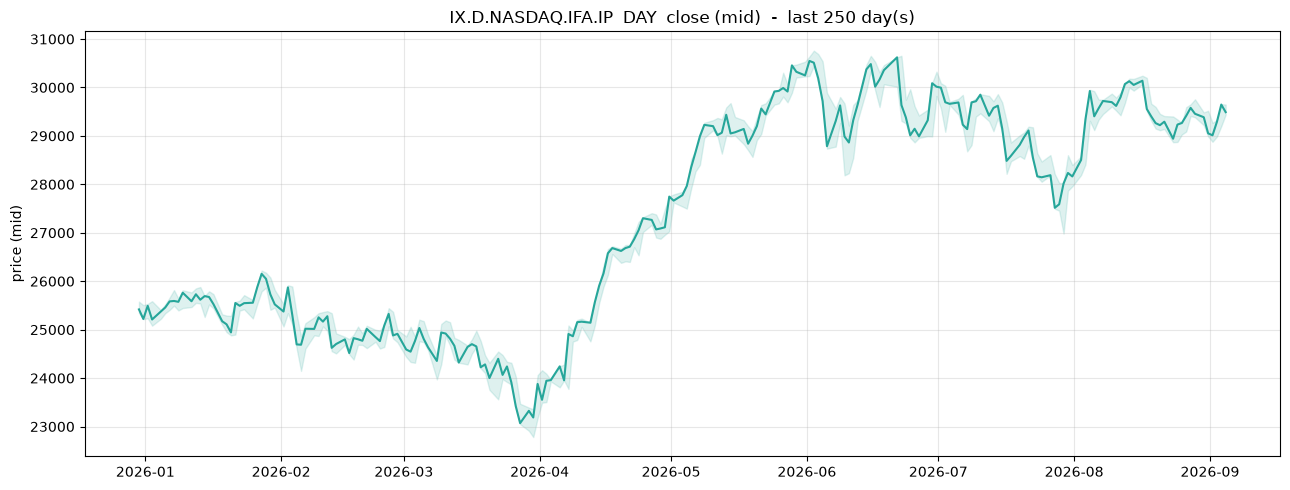

In [7]:
if df is None:
    print("Run the pandas cell above first.")
elif df.empty:
    print(
        f"No candles in {cfg.csv_path.name} - nothing to plot. "
        f"The download returned 0 {cfg.resolution} candles for the last "
        f"{cfg.days_back} day(s) (e.g. a weekend / market-closed window); "
        f"try a larger DAYS_BACK."
    )
else:
    try:
        import matplotlib.pyplot as plt
    except ModuleNotFoundError:
        print("matplotlib not installed - run:  %pip install matplotlib")
    else:
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(df.index, df["close_mid_price"], color="#26a69a")
        ax.fill_between(df.index, df["low_mid_price"], df["high_mid_price"], color="#26a69a", alpha=0.15)
        ax.set_title(f"{cfg.epic}  {cfg.resolution}  close (mid)  -  last {cfg.days_back} day(s)")
        ax.set_ylabel("price (mid)")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()